In [1]:
%load_ext autoreload
%autoreload 2
import import_before_profile


In [3]:
import equinox as eqx
import jax
import jax.numpy as jnp

from import_me_for_testing import N_max_exps, aux_data, boundaries, dist, model
from qdots_qll.data import Data
from qdots_qll.distributions import (
    Distribution,
    update_log_weights,
)
from qdots_qll.exp_design import GameExpDesignTimeAdaptivity, RandExpDesignGAME, GameExpDesignFullAdaptivity
from qdots_qll.experiments import ExperimentSingleDotWeakCouplingGAME
from qdots_qll.models.single_dot_weak_coupling_GAME import (
    SingleDotWeakCouplingGAME,
)
from qdots_qll.resamplers import LiuWestResampler, MetropolisSampler
from qdots_qll.smc import SMCUpdater, replace_single_datum, replace_single_exp

key = jax.random.key(0)
key, subkey = jax.random.split(key)

In [172]:
edesign = GameExpDesignFullAdaptivity(
    0.01,
    40.0,
)

In [173]:
prob_rho0 = jnp.ones(4) / 4
prob_basis = jnp.ones(3) / 3

In [179]:
key, subkey = jax.random.split(key)
experiment, prob_rho0, prob_basis = edesign.generate_experiment(subkey, dist, model, prob_rho0, prob_basis)


print(prob_rho0)
print(prob_basis)

print(experiment.initial_state)
print(experiment.measurement_basis)

[0.44619015 0.2580681  0.         0.2957417 ]
[0.0082157  0.         0.99178433]
[1]
[2]


In [229]:
from qdots_qll.exp_design import choose_from_dist

key, subkey = jax.random.split(key)

choose_from_dist(subkey, prob_basis)

Array(2, dtype=int32)

In [37]:
prob_rho0[2]

Array(0., dtype=float32)

In [41]:
experiment.initial_state

Array([0], dtype=int8)

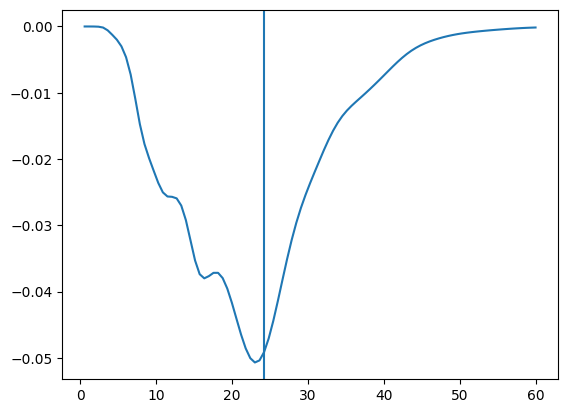

In [17]:
import matplotlib.pyplot as plt

true_dist = Distribution(
    particles_locations=jnp.repeat(model.true_parameters[None, :], 50, axis=0),
    weights=jnp.ones(50) / 50,
)
key, subkey = jax.random.split(key)
opt_time = edesign.generate_experiment(subkey, true_dist, model, prob_rho0, prob_basis)

times = jnp.linspace(0, 60, 100)
det_fim_times = jax.vmap(
    edesign.loss_fn(model.true_parameters, model, prob_rho0, prob_basis)
)(times)

plt.plot(times, det_fim_times)
plt.axvline(opt_time.time)

In [18]:
# comparing the different prob distributions
# there is a total of 12 combinations
configurations = []
for i in range(4):
    for j in range(3):
        temp_prob_rho0 = [1 if k == i else 0 for k in range(4)]
        temp_basis = [1 if k == j else 0 for k in range(3)]
        temp_config = [jnp.array(temp_prob_rho0), jnp.array(temp_basis)]
        configurations.append(temp_config)


DEBUG:2024-09-11 13:57:49,887:jax._src.compiler:166: get_compile_options: num_replicas=1 num_partitions=1 device_assignment=[[CudaDevice(id=0)]]
DEBUG:2024-09-11 13:57:49,888:jax._src.compiler:230: get_compile_options XLA-AutoFDO profile: using XLA-AutoFDO profile version -1
DEBUG:2024-09-11 13:57:49,890:jax._src.lru_cache:107: Cache hit for key: 'jit_convert_element_type-315599c97ea653eb39f1364d044b43e5f0cd1f044a442e122876ac3b093a943c'
DEBUG:2024-09-11 13:57:49,892:jax._src.compiler:98: Persistent compilation cache hit for 'jit_convert_element_type' with key 'jit_convert_element_type-315599c97ea653eb39f1364d044b43e5f0cd1f044a442e122876ac3b093a943c'
DEBUG:2024-09-11 13:57:49,899:jax._src.compiler:166: get_compile_options: num_replicas=1 num_partitions=1 device_assignment=[[CudaDevice(id=0)]]
DEBUG:2024-09-11 13:57:49,900:jax._src.compiler:230: get_compile_options XLA-AutoFDO profile: using XLA-AutoFDO profile version -1
DEBUG:2024-09-11 13:57:49,901:jax._src.lru_cache:107: Cache hit fo

In [19]:
# times = jnp.linspace(0, 60, 100)

# for config in configurations:
#     conf_p_rho0 = config[0]
#     conf_p_basis = config[1]
#     det_fim_times = jax.vmap(
#         edesign.loss_fn(model.true_parameters, model, conf_p_rho0, conf_p_basis)
#     )(times)

#     plt.plot(times, det_fim_times)
#     plt.show()


In [20]:
from qdots_qll.exp_design import sgd_loop

In [21]:
def loss_fn(
    estimated_particle,
    model,
):
    def curried_loss(config_dict):
        t = config_dict["time"]
        prho0 = config_dict["initial_state"]
        pbasis = config_dict["measurement"]
        return -1 * jnp.linalg.det(
            model.fim(
                t=t,
                particle=estimated_particle,
                prob_initial_state=prho0,
                prob_measurement_basis=pbasis,
            )
        )

    return curried_loss


In [22]:
loss = loss_fn(
    model.true_parameters,
    model,
)
grad_loss = jax.jit(
    jax.grad(
        loss,
    )
)


In [104]:
import optax

optimizer = optax.sgd(learning_rate=0.1)
t0 = jnp.array(23.0, float)
params = {"time": t0, "initial_state": prob_rho0, "measurement": prob_basis}
opt_state = optimizer.init(params)

In [105]:
for _ in range(10):
    grads = grad_loss(params)

    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    params["initial_state"] = optax.projections.projection_simplex(
        params["initial_state"]
    )
    params["measurement"] = optax.projections.projection_simplex(params["measurement"])

print(grads)
print(params)


{'initial_state': Array([-0.644513  , -0.5451319 , -0.2817366 , -0.58012146], dtype=float32), 'measurement': Array([-0.51242447, -0.21746701, -0.7278472 ], dtype=float32), 'time': Array(-0.00040992, dtype=float32)}
{'initial_state': Array([0.38305664, 0.18921083, 0.11398977, 0.31374273], dtype=float32), 'measurement': Array([0.35870862, 0.15855078, 0.4827406 ], dtype=float32), 'time': Array(23.000324, dtype=float32)}


In [102]:
def loss_1(
    estimated_particle,
    model,
):
    def curried_loss(t, prho0, pbasis):
        return -1 * jnp.linalg.det(
            model.fim(
                t=t,
                particle=estimated_particle,
                prob_initial_state=prho0,
                prob_measurement_basis=pbasis,
            )
        )

    return curried_loss

l1 = loss_1(model.true_parameters, model)
unoptimized_loss_times = jax.vmap(l1, in_axes=(0, None, None))(times, prob_rho0, prob_basis)
optimized_loss_times = jax.vmap(l1, in_axes=(0, None, None))(times, params['initial_state'], params['measurement'])


In [40]:
params["initial_state"]

Array([0.43579805, 0.2511137 , 0.        , 0.3130883 ], dtype=float32)

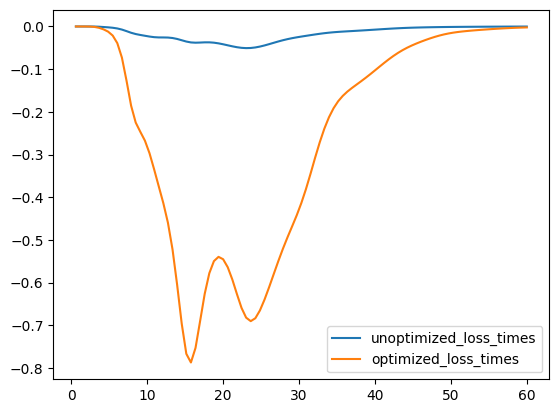

In [103]:
plt.plot(times, unoptimized_loss_times, label='unoptimized_loss_times')
plt.plot(times, optimized_loss_times, label='optimized_loss_times')
plt.legend()
plt.show()

In [37]:
grads

{'initial_state': Array([-3978.723 , -1269.7202, -1196.5255, -2114.228 ], dtype=float32),
 'measurement': Array([-2917.8384, -1153.883 , -3923.1147], dtype=float32),
 'time': Array(376.17938, dtype=float32)}

In [73]:
params["state"] = optax.projections.projection_simplex(params["state"])
params["measurement"] = optax.projections.projection_simplex(params["measurement"])

(Array(0.00178371, dtype=float32),
 Array([-0.10503736, -0.03417848, -0.03458615, -0.05686814], dtype=float32),
 Array([-0.06232959, -0.0266786 , -0.08399439], dtype=float32))